# House Price Prediction using Machine Learning

### Predicting House Prices using Linear Regression

## Import Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

## Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("../data/HousePricePrediction.csv")

# Display the first five rows
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


## Dataset Overview

In [3]:
# Display the shape of the dataset
df.shape

(2919, 13)

In [4]:
# Display column names
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [5]:
# Display column names
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [6]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [7]:
# Display summary statistics
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [8]:
# Check for missing values
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [9]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Observation

- The dataset contains **2919 rows** and **13 columns**.
- The target variable is **SalePrice**.
- There are **6 integer**, **3 float**, and **4 categorical** features.
- Missing values are present in **MSZoning, Exterior1st, BsmtFinSF2, TotalBsmtSF, and SalePrice**.
- The **SalePrice** column contains **1459 missing values**, indicating that part of the dataset does not have target labels.
- No duplicate rows were found in the dataset.

## Data Cleaning

In [10]:
# Display rows where SalePrice is missing
df[df["SalePrice"].isnull()]

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
1460,1460,20,RH,11622,Inside,1Fam,6,1961,1961,VinylSd,144.0,882.0,NaN
1461,1461,20,RL,14267,Corner,1Fam,6,1958,1958,Wd Sdng,0.0,1329.0,NaN
1462,1462,60,RL,13830,Inside,1Fam,5,1997,1998,VinylSd,0.0,928.0,NaN
1463,1463,60,RL,9978,Inside,1Fam,6,1998,1998,VinylSd,0.0,926.0,NaN
1464,1464,120,RL,5005,Inside,TwnhsE,5,1992,1992,HdBoard,0.0,1280.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [50]:
# Create training dataset (rows with SalePrice)
train_df = df[df["SalePrice"].notnull()].copy()

# Create test dataset (rows without SalePrice)
test_df = df[df["SalePrice"].isnull()].copy()

# verify the shape
train_df.shape

(1460, 13)

In [12]:
# Check missing values in training dataset
train_df.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

### Observation

- The original dataset was separated into training and test datasets.
- The training dataset contains houses with known sale prices.
- The test dataset contains houses without sale prices and will be used for future predictions.
- No missing values are present in the training dataset.
- The training dataset is ready for Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

### Distribution of SalePrice

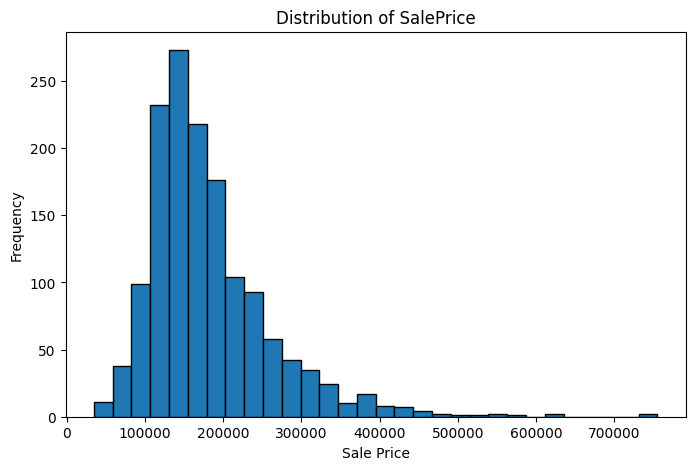

In [13]:
# Plot the distribution of SalePrice

plt.figure(figsize = (8, 5))
plt.hist(train_df["SalePrice"], bins = 30, edgecolor = "black")

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Observation

- The distribution of `SalePrice` is positively (right) skewed.
- Most houses are concentrated between 100,000 and 250,000.
- The number of houses decreases as the sale price increases.
- A small number of houses have very high sale prices, suggesting potential outliers.
- The target variable is not normally distributed.

### Detecting Outliers in SalePrice

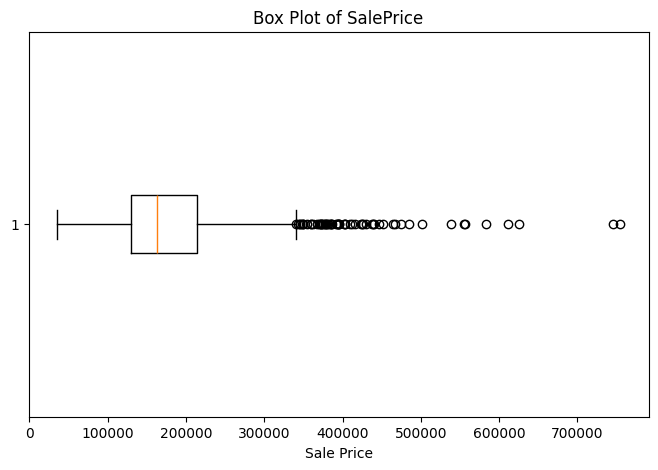

In [14]:
# Box plot of SalePrice

plt.figure(figsize = (8, 5))
plt.boxplot(train_df["SalePrice"], vert = False)

plt.title("Box Plot of SalePrice")
plt.xlabel("Sale Price")

plt.show()

### Observation

- The box plot shows several potential outliers on the higher end of the `SalePrice` distribution.
- The median sale price lies closer to the lower quartile, indicating a right-skewed distribution.
- Most houses fall within a relatively smaller price range, while a few houses have significantly higher sale prices.
- These outliers are likely to represent genuine high-value properties rather than data errors.
- Therefore, the outliers will be retained for further analysis and model building.

### Relationship Between Total Basement Area and SalePrice

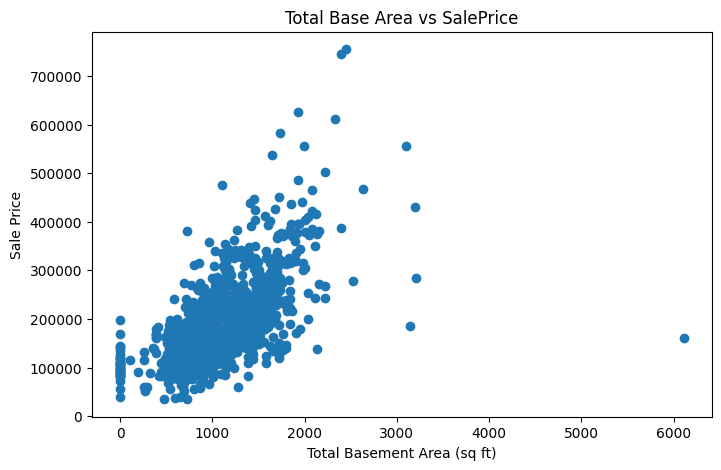

In [15]:
# Scatter Plot of TotalBsmtSF vs SalePrice

plt.figure(figsize = (8, 5))
plt.scatter(train_df["TotalBsmtSF"], train_df["SalePrice"])

plt.title("Total Base Area vs SalePrice")
plt.xlabel("Total Basement Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()

### Observation

- A moderately strong positive relationship exists between `TotalBsmtSF` and `SalePrice`.
- Houses with larger basement areas generally tend to have higher sale prices.
- The scatter of points indicates that basement area is an important feature, but other factors also influence house prices.
- A few potential outliers are present, but they appear to represent valid observations.

### Relationship Between Numerical Features and SalePrice

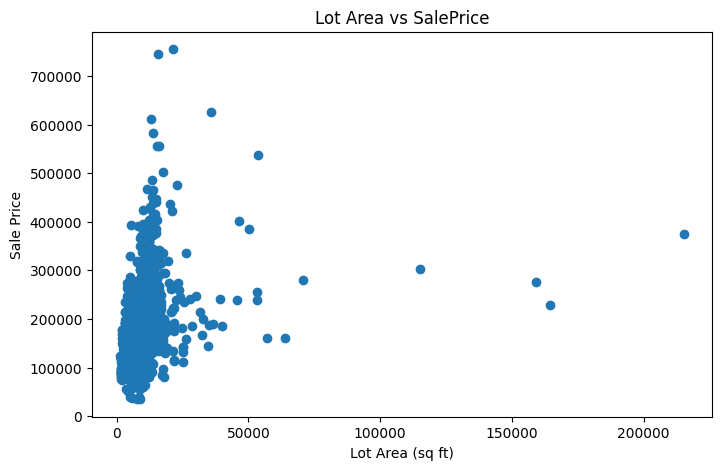

In [16]:
# Scatter plot: LotArea vs Sale price

plt.figure(figsize = (8, 5))
plt.scatter(train_df["LotArea"], train_df["SalePrice"])

plt.title("Lot Area vs SalePrice")
plt.xlabel("Lot Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()

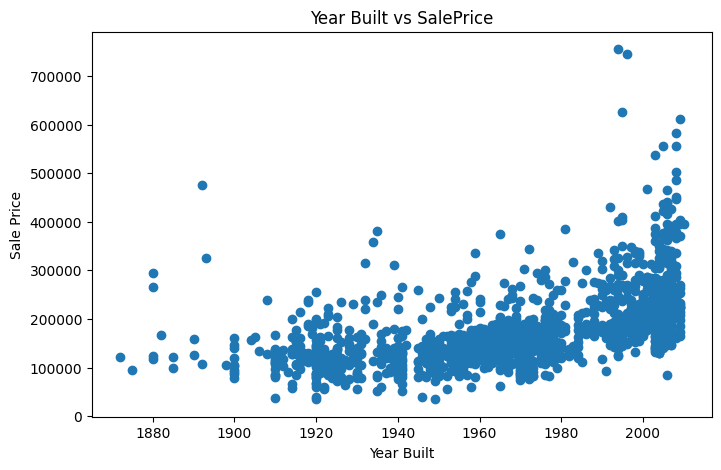

In [17]:
# Scatter plot: YearBuilt vs Sale price

plt.figure(figsize = (8, 5))
plt.scatter(train_df["YearBuilt"], train_df["SalePrice"])

plt.title("Year Built vs SalePrice")
plt.xlabel("Year Built")
plt.ylabel("Sale Price")

plt.show()

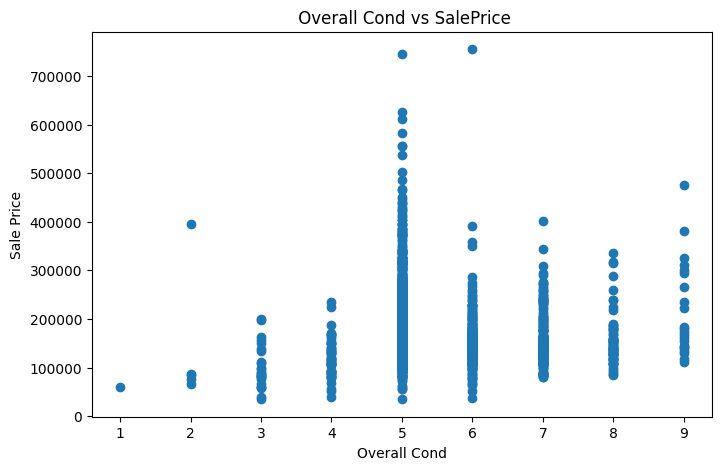

In [18]:
# Scatter plot: OverallCond vs Sale price

plt.figure(figsize = (8, 5))
plt.scatter(train_df["OverallCond"], train_df["SalePrice"])

plt.title(" Overall Cond vs SalePrice")
plt.xlabel("Overall Cond")
plt.ylabel("Sale Price")

plt.show()

### Observation

- `TotalBsmtSF` shows the strongest positive relationship with `SalePrice`, indicating that houses with larger basement areas generally have higher sale prices.
- `YearBuilt` also has a strong positive relationship with `SalePrice`, suggesting that newer houses tend to sell at higher prices.
- `LotArea` shows only a weak positive relationship, indicating that larger plots of land do not necessarily result in higher sale prices.
- `OverallCond` has a relatively weak relationship with `SalePrice`, as houses with similar condition ratings exhibit a wide range of sale prices.
- Overall, `TotalBsmtSF` and `YearBuilt` appear to be more influential predictors of house prices than `LotArea` and `OverallCond`.

### Correlation Analysis

In [19]:
# Correlation Matrix for numerical features

correlation_matrix = train_df.corr(numeric_only = True)

correlation_matrix

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
Id,1.000000,0.011156,-0.033226,0.012609,-0.012713,-0.021998,-0.005968,-0.015415,-0.021917
MSSubClass,0.011156,1.000000,-0.139781,-0.059316,0.027850,0.040581,-0.065649,-0.238518,-0.084284
LotArea,-0.033226,-0.139781,1.000000,-0.005636,0.014228,0.013788,0.111170,0.260833,0.263843
OverallCond,0.012609,-0.059316,-0.005636,1.000000,-0.375983,0.073741,0.040229,-0.171098,-0.077856
YearBuilt,-0.012713,0.027850,0.014228,-0.375983,1.000000,0.592855,-0.049107,0.391452,0.522897
YearRemodAdd,-0.021998,0.040581,0.013788,0.073741,0.592855,1.000000,-0.067759,0.291066,0.507101
BsmtFinSF2,-0.005968,-0.065649,0.111170,0.040229,-0.049107,-0.067759,1.000000,0.104810,-0.011378
TotalBsmtSF,-0.015415,-0.238518,0.260833,-0.171098,0.391452,0.291066,0.104810,1.000000,0.613581
SalePrice,-0.021917,-0.084284,0.263843,-0.077856,0.522897,0.507101,-0.011378,0.613581,1.000000


### Observation

- `TotalBsmtSF` has the strongest positive correlation with `SalePrice` (0.614), indicating it is one of the most influential numerical features.
- `YearBuilt` and `YearRemodAdd` also show moderate positive correlations with `SalePrice`, suggesting that newer and recently remodeled houses generally have higher sale prices.
- `LotArea` has a weak positive correlation with `SalePrice`, indicating that lot size alone has a limited impact on house prices.
- `OverallCond` and `BsmtFinSF2` show very weak correlations with `SalePrice`, suggesting they have less influence individually.
- The correlation results are consistent with the patterns observed in the scatter plots.

### Correlation Heatmap

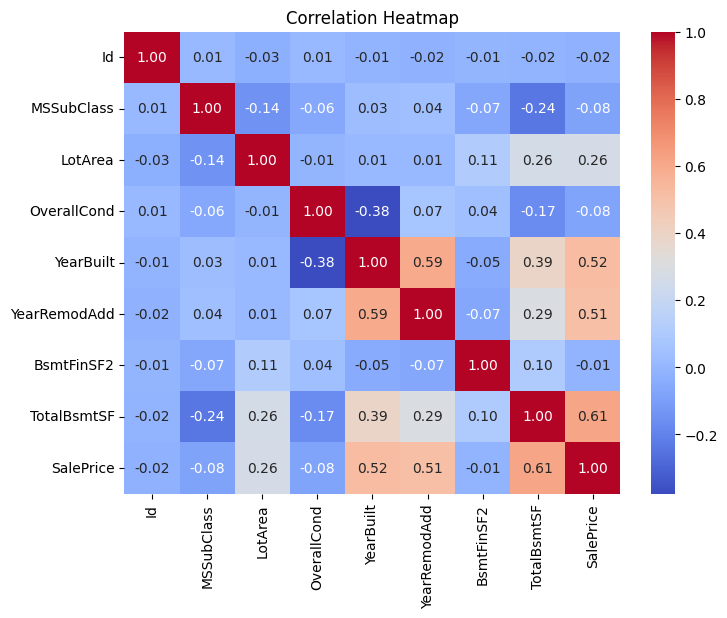

In [20]:
plt.figure(figsize = (8, 6))

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The heatmap confirms that `TotalBsmtSF` has the strongest positive correlation with `SalePrice` (0.61), making it one of the most influential numerical features.
- `YearBuilt` (0.52) and `YearRemodAdd` (0.51) also show moderate positive correlations, indicating that newer and recently remodeled houses generally have higher sale prices.
- `LotArea` has a weak positive correlation (0.26), suggesting that larger plots of land alone do not strongly determine house prices.
- `OverallCond`, `MSSubClass`, and `BsmtFinSF2` have very weak correlations with `SalePrice`, indicating that they contribute less when considered individually.
- Overall, the heatmap validates the insights obtained from the scatter plots and correlation analysis, helping identify the most relevant numerical features for model building.

## Feature Engineering and Data Preprocessing

### Identify Categorical and Numerical Features

In [29]:
# Seprate numerical and categorical features

numerical_features = train_df.select_dtypes(include = ["int64", "float64"]).columns
categorical_features = train_df.select_dtypes(include = ["object"]).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice'],
      dtype='object')

Categorical Features:
Index([], dtype='object')


### Encode Categorical Features

In [33]:
# Applying One-Hot Encoding to categorical features

train_df = pd.get_dummies(
    train_df, 
    columns = categorical_features,
    drop_first = True
)
train_df.head()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0,False,...,False,False,False,False,False,False,False,True,False,False
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0,False,...,False,False,False,True,False,False,False,False,False,False
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0,False,...,False,False,False,False,False,False,False,True,False,False
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0,False,...,False,False,False,False,False,False,False,False,True,False
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0,False,...,False,False,False,False,False,False,False,True,False,False


### Observation

- Categorical features were converted into numerical features using One-Hot Encoding.
- The `drop_first=True` parameter was used to avoid the Dummy Variable Trap and reduce multicollinearity.
- Each category is represented as a separate binary (Boolean) feature, making the dataset suitable for Linear Regression.
- The encoded dataset is now ready for feature selection and model training.

### Feature Selection

In [31]:
# Separate features and target variable

X = train_df.drop(columns = ["Id", "SalePrice"])
y = train_df["SalePrice"]

print("Features shape: ", X.shape)
print("Target shape: ", y.shape)

Features shape:  (1460, 33)
Target shape:  (1460,)


### Observation

- The dataset was successfully divided into input features (`X`) and the target variable (`y`).
- The feature set contains 33 predictor variables and 1460 observations.
- The target variable contains the sale price for all 1460 houses.
- The dataset is now ready for splitting into training and testing sets.

### Train-Test Split

In [34]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1168, 33)
Testing Features: (292, 33)
Training Target: (1168,)
Testing Target: (292,)


### Observation

- The dataset was successfully split into training and testing sets using an 80:20 ratio.
- The training set contains 1168 observations, while the testing set contains 292 observations.
- Both training and testing feature sets contain 33 predictor variables.
- The split ensures that the model is trained on one portion of the data and evaluated on unseen data, helping measure its generalization performance.

## Model Training

### Train the linear Regression Model

In [35]:
# Create the Linear Regression Model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Make Predictions

In [37]:
# Predict house price using the test dataset
y_pred = model.predict(X_test)

# display the first five predictions
print(y_pred[:5])

[168844.20187045 243627.93266265 114499.46802618 157672.74928534
 254809.72691561]


In [39]:
# Comparing actual and predicted values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
0,154500.0,168844.201870
1,325000.0,243627.932663
2,115000.0,114499.468026
3,159000.0,157672.749285
4,315500.0,254809.726916


## Model Evaluation

### Evaluate Model Performance

In [40]:
# calculate Mean Absolute Error (MAE)

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 34122.85443215002


### Observation

- The model achieved a Mean Absolute Error (MAE) of **34,122.85**.
- This indicates that, on average, the predicted house prices differ from the actual prices by approximately **34,123**.
- A lower MAE indicates better predictive performance.
- Considering this is the initial Linear Regression model, the result provides a reasonable baseline for further improvement.

In [44]:
# Calculate Mean Squared Error (MSE)

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 2918458029.5854945


### Observation

- The model achieved a Mean Squared Error (MSE) of **2,918,458,029.59**.
- MSE measures the average squared difference between actual and predicted values.
- Because the errors are squared, larger prediction errors receive a much higher penalty.
- The MSE value is difficult to interpret directly because it is expressed in squared units.

In [43]:
# Calculate Root Mean Squared Error (RMSE)
rmse = root_mean_squared_error(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 54022.75473895694


### Observation

- The model achieved a Root Mean Squared Error (RMSE) of **54,022.75**.
- RMSE indicates that the model's predictions differ from the actual house prices by approximately **54,023**, on average.
- RMSE penalizes large prediction errors more heavily than MAE, making it useful when larger errors are more costly.
- Since RMSE is expressed in the same unit as the target variable, it is easier to interpret than MSE.

In [45]:
# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6195131796544862


### Observation

- The Linear Regression model achieved an R² score of **0.62**, indicating that it explains approximately **62% of the variation** in house prices.
- The Mean Absolute Error (MAE) of **34,122.85** indicates that the model's predictions differ from the actual prices by about **34,123**, on average.
- The Root Mean Squared Error (RMSE) of **54,022.75** is higher than the MAE, suggesting that a few predictions have relatively large errors.
- Overall, the model provides a reasonable baseline for house price prediction and can be further improved through feature engineering, hyperparameter tuning, or more advanced regression algorithms.

## Predict House Prices for Unseen Data

In [51]:
# Create a copy of the unseen test data
prediction_df = test_df.copy()

In [52]:
# Fill missing values using the same strategy as the training data

# Categorical columns
prediction_df["MSZoning"] = prediction_df["MSZoning"].fillna(
    prediction_df["MSZoning"].mode()[0]
)

prediction_df["Exterior1st"] = prediction_df["Exterior1st"].fillna(
    prediction_df["Exterior1st"].mode()[0]
)

# Numerical columns
prediction_df["BsmtFinSF2"] = prediction_df["BsmtFinSF2"].fillna(
    prediction_df["BsmtFinSF2"].median()
)

prediction_df["TotalBsmtSF"] = prediction_df["TotalBsmtSF"].fillna(
    prediction_df["TotalBsmtSF"].median()
)

In [55]:
# Apply One-Hot Encoding

prediction_df = pd.get_dummies(
    prediction_df,
    columns = categorical_features,
    drop_first = True
)

In [56]:
# Prepare the unseen dataset for prediction

prediction_features = prediction_df.drop(columns = ["Id", "SalePrice"])

# Match the columns with the training data
prediction_features = prediction_features.reindex(
    columns = X.columns,
    fill_value = 0
)

In [58]:
# Predict house prices for the unseen dataset

predicted_prices = model.predict(prediction_features)

In [61]:
# Create a dataframe containing the predictions

submission = pd.DataFrame({
    "Id": prediction_df["Id"],
    "SalePrice": predicted_prices
})

submission.head()

,Id,SalePrice
1460,1460,101107.983156
1461,1461,137871.674674
1462,1462,194689.571645
1463,1463,196969.366352
1464,1464,263175.424229


In [66]:
# Save the predictions as a CSV file

submission.to_csv(
    "..\outputs\house_price_prediction.csv",
    index = False
)

print("Prediction file saved successfully.")

Prediction file saved successfully.


## Prediction Summary

The trained Linear Regression model was successfully used to predict house prices for the unseen dataset.

The same preprocessing steps applied to the training data were also applied to the unseen data to ensure consistency. After preprocessing and feature alignment, the model generated predicted sale prices for all houses without target values.

This demonstrates a complete end-to-end machine learning workflow, from data preprocessing and model training to making predictions on new, unseen data.

# Conclusion

This project successfully developed a Linear Regression model to predict residential house prices using historical housing data.

The project followed a complete machine learning workflow, including data cleaning, exploratory data analysis, feature preprocessing, model training, evaluation, and prediction on unseen data.

### Key Outcomes

- Cleaned and prepared the dataset by handling missing values.
- Performed Exploratory Data Analysis (EDA) to understand feature distributions and relationships.
- Applied One-Hot Encoding to convert categorical variables into numerical features.
- Trained a Linear Regression model using an 80:20 train-test split.
- Evaluated the model using MAE, MSE, RMSE, and R² Score.
- Achieved an R² Score of approximately **0.62**, indicating that the model explains around **62%** of the variation in house prices.
- Successfully predicted house prices for previously unseen houses and exported the predictions as a CSV file.

Overall, this project demonstrates a complete end-to-end regression pipeline and strengthened my understanding of data preprocessing, exploratory data analysis, feature engineering, regression modeling, model evaluation, and prediction on unseen data.

## Future Improvements

Possible enhancements for this project include:

- Compare Linear Regression with advanced regression algorithms such as Decision Tree, Random Forest, XGBoost, and Gradient Boosting.
- Perform advanced feature engineering to improve model performance.
- Apply hyperparameter tuning for better predictive accuracy.
- Build an interactive web application using Streamlit for real-time house price prediction.
- Deploy the trained model as a web application or API for practical use.